# Semantic Search Engine

This notebook explores how embeddings represent the meaning of text as vectors.

We will use engineering failure descriptions related to embedded systems and SPI communication.

## Experiments

- Generate embeddings for engineering failures
- Understand embedding vectors
- Calculate cosine similarity
- Compare semantically similar and unrelated sentences
- Build a simple semantic search engine
- Return the top-K most similar failures

## Goal

Understand how embeddings allow a system to find text with similar meaning,
even when the exact words are different.

In [1]:
from sentence_transformers import SentenceTransformer
#SentenceTransformer is a class that lets us load a pretrained 
# model capable of converting sentences into vectors.
#Conceptually:

# "SPI timeout"
   #   ↓
#Embedding model
    #  ↓
#[0.12, -0.43, 0.87, ...]

In [2]:
model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [3]:
failures = [
    'spi timeout', 'spi crc error','clock mismatch','lens motor stalled', 'power rail unstable'
]

In [4]:
embeddings = model.encode(failures) #takes our five sentences and sends them through the pretrained model.
print('no of sentences: ', len(embeddings))
print('embedding shape: ', embeddings.shape) #That means:5 sentences  × 384 numbers per sentence


no of sentences:  5
embedding shape:  (5, 384)


In [5]:
print(embeddings[0]) #These vectors exist in something called embedding space.

[-1.24599999e-02 -7.52514275e-03 -1.66119337e-02  2.11557024e-03
 -9.78118367e-03 -2.98973471e-02  2.05766317e-03 -3.85218076e-02
  2.01618299e-02 -7.59381503e-02  5.51286228e-02  3.95369232e-02
 -5.06670512e-02  6.49111485e-03 -1.44257667e-02  2.89571844e-03
 -5.48359975e-02 -6.81158304e-02 -3.88954133e-02 -1.16201229e-02
  4.79402393e-02 -1.36113884e-02 -1.14318572e-01  9.06347334e-02
 -1.13018066e-01 -1.68553740e-02 -1.49155213e-02 -3.89251560e-02
 -4.37115394e-02  5.62696382e-02  1.32454373e-02  7.20550343e-02
 -3.56356464e-02 -8.01780671e-02  2.66668350e-02  4.05051671e-02
 -1.57713518e-02  5.72824925e-02  9.67653841e-02 -2.66321450e-02
  5.94246015e-02 -1.42144496e-02 -4.46217768e-02 -3.95172797e-02
  1.22056395e-01 -8.17764027e-04  3.82641666e-02 -5.61608858e-02
  3.08683468e-03  4.26007099e-02 -6.13897182e-02  5.35775051e-02
  7.64720812e-02 -1.09736798e-02  8.35058186e-03  6.87212944e-02
 -1.38094183e-02  3.20096239e-02  2.05604024e-02  3.36084627e-02
  2.22688983e-03 -6.41023

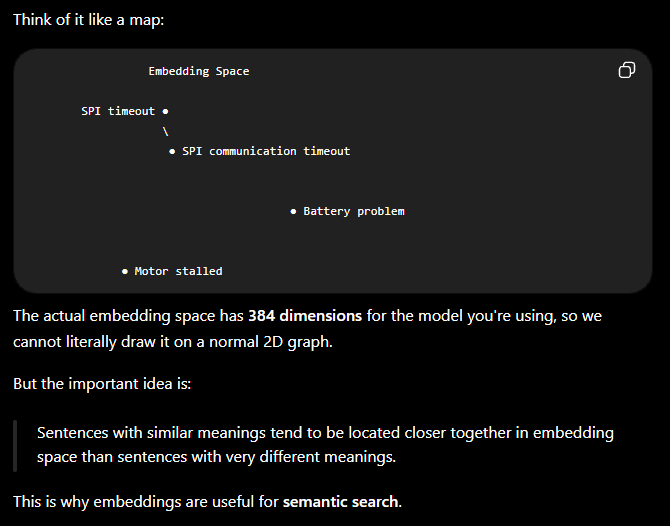

In [6]:
embeddings = model.encode(failures) #The model converts language into numbers.

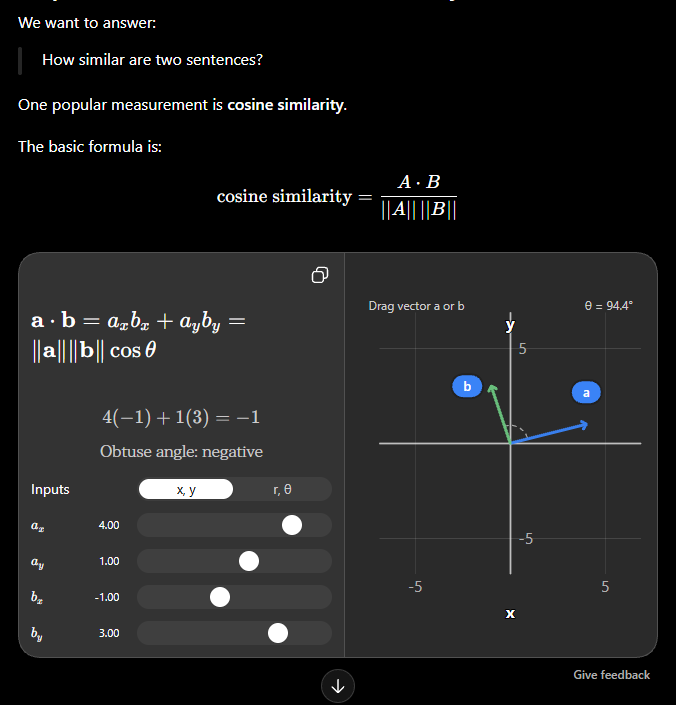

cosine similarity compares the direction of two vectors.
1 = very similar direction
0 = little similarity
-1 = opp direction


In [7]:
from sklearn.metrics.pairwise import cosine_similarity #Why? Instead of manually implementing the formula, we're using a function that already knows how to calculate cosine similarity.

In [8]:
for i , failure in enumerate(failures):
    print(i, failure)

0 spi timeout
1 spi crc error
2 clock mismatch
3 lens motor stalled
4 power rail unstable


In [9]:
embeddings[0]

array([-1.24599999e-02, -7.52514275e-03, -1.66119337e-02,  2.11557024e-03,
       -9.78118367e-03, -2.98973471e-02,  2.05766317e-03, -3.85218076e-02,
        2.01618299e-02, -7.59381503e-02,  5.51286228e-02,  3.95369232e-02,
       -5.06670512e-02,  6.49111485e-03, -1.44257667e-02,  2.89571844e-03,
       -5.48359975e-02, -6.81158304e-02, -3.88954133e-02, -1.16201229e-02,
        4.79402393e-02, -1.36113884e-02, -1.14318572e-01,  9.06347334e-02,
       -1.13018066e-01, -1.68553740e-02, -1.49155213e-02, -3.89251560e-02,
       -4.37115394e-02,  5.62696382e-02,  1.32454373e-02,  7.20550343e-02,
       -3.56356464e-02, -8.01780671e-02,  2.66668350e-02,  4.05051671e-02,
       -1.57713518e-02,  5.72824925e-02,  9.67653841e-02, -2.66321450e-02,
        5.94246015e-02, -1.42144496e-02, -4.46217768e-02, -3.95172797e-02,
        1.22056395e-01, -8.17764027e-04,  3.82641666e-02, -5.61608858e-02,
        3.08683468e-03,  4.26007099e-02, -6.13897182e-02,  5.35775051e-02,
        7.64720812e-02, -

In [10]:
similarity = cosine_similarity(
    [embeddings[0]],
    [embeddings[1]]
)

print('similarity: ', similarity[0],[0])

similarity:  [0.5326729] [0]


In [11]:
sentence_a = "SPI timeout"

sentence_b = "SPI communication timed out"

In [12]:
embeddings_a = model.encode([sentence_a])
embeddings_b = model.encode([sentence_b])
print('embeddings_a is: ',embeddings_a)
print('embeddings_b is: ',embeddings_b)

embeddings_a is:  [[-1.24599701e-02 -7.52510177e-03 -1.66119169e-02  2.11561285e-03
  -9.78121068e-03 -2.98973769e-02  2.05768179e-03 -3.85218002e-02
   2.01618075e-02 -7.59381503e-02  5.51286191e-02  3.95369753e-02
  -5.06670736e-02  6.49119075e-03 -1.44257499e-02  2.89569609e-03
  -5.48359975e-02 -6.81158304e-02 -3.88954170e-02 -1.16201825e-02
   4.79402542e-02 -1.36113660e-02 -1.14318535e-01  9.06346887e-02
  -1.13018073e-01 -1.68553740e-02 -1.49154617e-02 -3.89252082e-02
  -4.37115319e-02  5.62696084e-02  1.32454373e-02  7.20549971e-02
  -3.56356539e-02 -8.01780224e-02  2.66668089e-02  4.05051261e-02
  -1.57713369e-02  5.72824813e-02  9.67653692e-02 -2.66321208e-02
   5.94245903e-02 -1.42144626e-02 -4.46217395e-02 -3.95172648e-02
   1.22056417e-01 -8.17710184e-04  3.82641740e-02 -5.61609492e-02
   3.08683328e-03  4.26007174e-02 -6.13896959e-02  5.35775125e-02
   7.64721185e-02 -1.09736798e-02  8.35057348e-03  6.87212944e-02
  -1.38094062e-02  3.20095755e-02  2.05603689e-02  3.36084

In [13]:
similarity = cosine_similarity(embeddings_a,embeddings_b)
print('similarity: ', similarity[0][0])

similarity:  0.8037552


In [14]:
sentence_a = "SPI timeout"

sentence_b = "The battery temperature is high"

embedding_a = model.encode([sentence_a])
embedding_b = model.encode([sentence_b])

similarity = cosine_similarity(
    embedding_a,
    embedding_b
)

print("Similarity:", similarity[0][0])

Similarity: 0.13515137


## Top-K Semantic Search

The user provides a query describing an engineering problem.

The system converts the query into an embedding and compares it
with the embeddings of all stored failure descriptions.

The most similar failures are returned as the Top-K results.

In [15]:
query = 'the spi communication stopped because of a timeout'
print('query:', query)

query: the spi communication stopped because of a timeout


In [16]:
query_embedding = model.encode([query]) #Convert the query into an embedding 
#[query] means we're giving the model a list containing one sentence.
print('query embedding shape:', query_embedding.shape)

query embedding shape: (1, 384)


In [17]:
similarities = cosine_similarity(
    
    query_embedding, embeddings
)

print(similarities)

[[0.8517333  0.4896558  0.18345028 0.24923012 0.16524675]]


In [18]:
import pandas as pd
results = []

for i in range(len(failures)):
    results.append({
        
        'failure' : failures[i],
        'similarity': similarities[0][i]
        
    })
    
    results_df = pd.DataFrame(results)
    results_df
    print(results_df)

       failure  similarity
0  spi timeout    0.851733
         failure  similarity
0    spi timeout    0.851733
1  spi crc error    0.489656
          failure  similarity
0     spi timeout    0.851733
1   spi crc error    0.489656
2  clock mismatch    0.183450
              failure  similarity
0         spi timeout    0.851733
1       spi crc error    0.489656
2      clock mismatch    0.183450
3  lens motor stalled    0.249230
               failure  similarity
0          spi timeout    0.851733
1        spi crc error    0.489656
2       clock mismatch    0.183450
3   lens motor stalled    0.249230
4  power rail unstable    0.165247


In [19]:
results_df = results_df.sort_values(
    'similarity',
    ascending = False #Sort from largest to smallest.
    
)
results_df

,failure,similarity
0,spi timeout,0.851733
1,spi crc error,0.489656
3,lens motor stalled,0.249230
2,clock mismatch,0.183450
4,power rail unstable,0.165247


In [20]:
k = 3
top_k_results = results_df.head(k)
top_k_results



,failure,similarity
0,spi timeout,0.851733
1,spi crc error,0.489656
3,lens motor stalled,0.249230


In [21]:
def semantic_search(query, k =3): #query → what the user wants to search for
#k → how many results we want
    query_embedding = model.encode([query])
    similarities = cosine_similarity(
        query_embedding, embeddings
    )
    
    results = []
    
    for i in range(len(failures)):
        results.append({
            'failure' : failures[i],
            'similarity': similarities[0][i]  
        })
        
        results_df = pd.DataFrame(results)
        results_df = results_df.sort_values(
            
            'similarity',
            ascending = False
        )
        
        return results_df.head(k)

## Cosine Similarity Visualizer

We will compare pairs of sentences and observe their cosine similarity.

The goal is to see how semantically similar sentences receive higher
similarity scores than unrelated sentences.

In [22]:
sentence_pairs = [
    
    ('spi timeout', 'spi communication times out'),
    ("SPI timeout", "SPI communication failed"),
    ("SPI timeout", "Battery temperature is high"),
    ("Lens motor stalled", "Lens motor stopped moving"),
    ("Power rail unstable", "Power supply voltage is unstable")  
]

In [ ]:
similarity_results =[] #Creates an empty list where we'll store the results.

for sentence_a,sentence_b in sentence_pairs: #takes each pair one at a time.
    embedding_a = model.encode([sentence_a]) #converts both sentences into vectors. Sentence A → Vector A
    embedding_b = model.encode([sentence_b]) #converts both sentences into vectors. Sentence B → Vector B
    
    #compares those two vectors and gives us one similarity score.
    similarity = cosine_similarity(   
        embedding_a,
        embedding_b
    )[0][0]
    
    #stores the result.
    similarity_results.append({
        
        'sentence a' : sentence_a,
        'sentence b' : sentence_b,
        'similarity' : similarity
        })

# OUTSIDE the loop
similarity_df = pd.DataFrame(similarity_results)
similarity_df

,sentence a,sentence b,similarity
0,spi timeout,spi communication times out,0.832977
1,SPI timeout,SPI communication failed,0.699492
2,SPI timeout,Battery temperature is high,0.060295
3,Lens motor stalled,Lens motor stopped moving,0.881390
4,Power rail unstable,Power supply voltage is unstable,0.622468


In [34]:
similarity_df['similarity'] = similarity_df['similarity'].round(3)
similarity_df

,sentence a,sentence b,similarity
0,spi timeout,spi communication times out,0.833
1,SPI timeout,SPI communication failed,0.699
2,SPI timeout,Battery temperature is high,0.060
3,Lens motor stalled,Lens motor stopped moving,0.881
4,Power rail unstable,Power supply voltage is unstable,0.622


In [35]:
similarity_df['pair'] = [
    
    "SPI timeout / SPI timed out",
    "SPI timeout / SPI failed",
    "SPI timeout / Battery high",
    "Motor stalled / Motor stopped",
    "Power unstable / Voltage unstable"
    
]

similarity_df

,sentence a,sentence b,similarity,pair
0,spi timeout,spi communication times out,0.833,SPI timeout / SPI timed out
1,SPI timeout,SPI communication failed,0.699,SPI timeout / SPI failed
2,SPI timeout,Battery temperature is high,0.060,SPI timeout / Battery high
3,Lens motor stalled,Lens motor stopped moving,0.881,Motor stalled / Motor stopped
4,Power rail unstable,Power supply voltage is unstable,0.622,Power unstable / Voltage unstable


<function matplotlib.pyplot.show(close=None, block=None)>

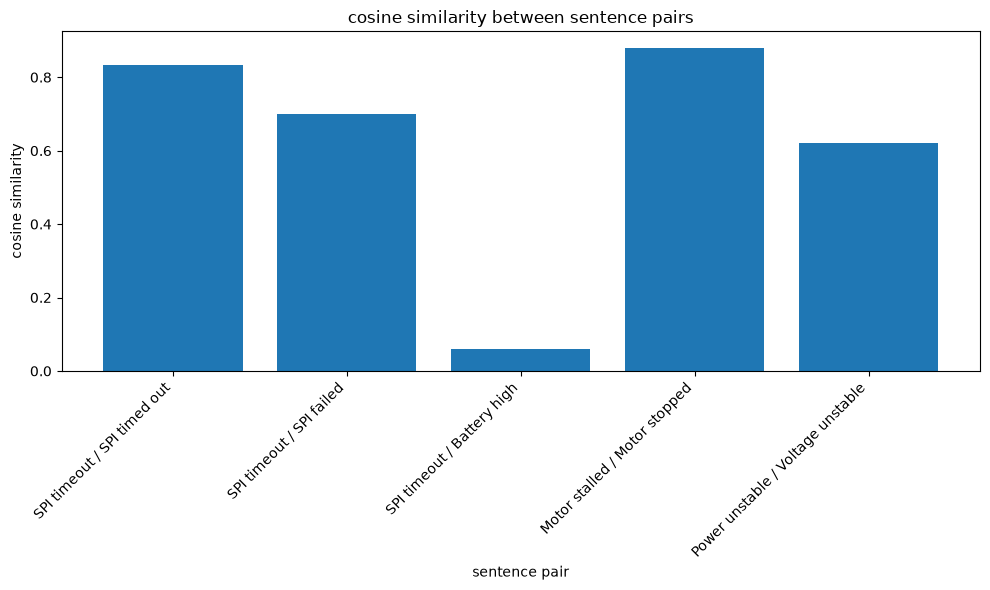

In [38]:
import matplotlib.pyplot as plt
plt.figure(figsize = (10,6))
plt.bar(
    similarity_df['pair'],
    similarity_df['similarity']    
)

plt.xticks(rotation = 45, ha='right')
plt.xlabel('sentence pair')
plt.ylabel('cosine similarity')

plt.title('cosine similarity between sentence pairs')
plt.tight_layout()
plt.show
          

Cosine similarity isn't saying:
"These sentences are identical."

It's saying:
"How similar are the directions of their embedding vectors?"

A score closer to 1 generally means stronger similarity.

## Cosine Similarity Observations

The sentence pairs with similar meanings generally produce higher cosine
similarity scores.

For example:

- "SPI timeout" and "SPI communication timed out" describe a similar problem.
- "Lens motor stalled" and "Lens motor stopped moving" describe a similar motor problem.
- "Power rail unstable" and "Power supply voltage is unstable" describe a similar power problem.
- "SPI timeout" and "Battery temperature is high" describe different problems.

This demonstrates how embeddings can capture semantic relationships
even when the exact wording is different.

# What I Learned

## 1. Embeddings

An embedding is a numerical representation of text.

The basic process is:

Text
↓
Embedding Model
↓
Dense Vector

For example:

"SPI timeout"
↓
[0.12, -0.43, 0.71, ...]

The numbers represent the sentence in a mathematical space.


## 2. Dense Vectors

An embedding is called a dense vector because most of its dimensions
contain numerical values.

Our `all-MiniLM-L6-v2` model produces a 384-dimensional vector.

Therefore:

5 sentences
↓
5 × 384 numerical values

The individual numbers are not interpreted separately.
The overall vector represents the semantic information learned by the model.


## 3. Embedding Space

Each sentence can be thought of as a point in a high-dimensional
embedding space.

Sentences with similar meanings tend to have similar positions
or directions in this space.

For example:

"SPI timeout"

and

"SPI communication timed out"

should be semantically closer than:

"SPI timeout"

and

"Battery temperature is high".


## 4. Cosine Similarity

Cosine similarity measures how similar two vectors are based on
the angle between them.

A value closer to 1 generally indicates stronger similarity.

A value closer to 0 generally indicates weaker similarity.

The mathematical range of cosine similarity is -1 to 1.

In our sentence-embedding experiments, we mainly observe positive
similarity values.


## 5. Dot Product

The dot product combines corresponding values from two vectors
and adds the results.

For vectors A and B:

A · B = A₁B₁ + A₂B₂ + ... + AₙBₙ

Dot products are an important building block in machine learning
and are also used when comparing vectors.


## 6. Euclidean Distance

Euclidean distance measures the straight-line distance between
two points in a vector space.

Smaller distance means the points are closer together.

Conceptually:

Similar vectors
→ smaller distance

Different vectors
→ larger distance

Cosine similarity and Euclidean distance measure similarity in
different ways.


## 7. Similarity Search

Similarity search means finding items whose embeddings are most
similar to a query embedding.

Our pipeline was:

User Query
↓
Query Embedding
↓
Compare with Stored Embeddings
↓
Calculate Similarity
↓
Sort Results
↓
Return Top-K


## 8. Semantic Search

Traditional keyword search mainly looks for matching words.

Semantic search uses embeddings to compare meaning.

Example:

Query:
"SPI communication stopped because of timeout"

Stored document:
"SPI communication timed out"

Even though the wording is different, their meanings are similar.

This is why semantic search is useful for engineering logs,
documentation, troubleshooting systems, and RAG applications.


## 9. Connection to RAG

Embeddings are an important part of Retrieval-Augmented Generation (RAG).

A simplified RAG pipeline is:

User Question
↓
Create Query Embedding
↓
Search Vector Database
↓
Retrieve Top-K Relevant Documents
↓
Give Retrieved Context to LLM
↓
Generate Answer

The semantic search engine built in this notebook represents
the retrieval part of this pipeline.


## 10. Key Takeaway

The main idea I learned is:

Text
↓
Embedding
↓
Vector
↓
Similarity
↓
Relevant Information

Embeddings allow machines to compare the meaning of text
mathematically.

This makes semantic search possible and provides the foundation
for modern RAG systems.